# Sampling in IXPLORE: Rasch vs Posterior (Smartvote 2023)

This notebook compares two sampling strategies for generating pseudo-answers for a **new candidate** 
who has answered only a subset of the 75 Smartvote questions (5-point Likert scale: 0, 0.25, 0.5, 0.75, 1.0):

1. **Rasch sampling** — uses the Rasch model's category response functions (normal PDFs centred at each answer option) 
   applied to the user's *imputed* continuous scores, then draws discrete samples via the Gumbel-max trick.
2. **Posterior sampling** — computes the full Bayesian posterior over the 2D latent space given the observed answers, 
   samples latent positions from that posterior, and predicts continuous probabilities from each sampled position.

All accuracy metrics (MAE) are computed **only on unobserved items** — the items the candidate has 
*not* answered — giving an honest measure of generalisation.

A **random baseline** (uniform sampling) is included for reference. The model is fitted 
on 1029 candidates from the Smartvote 2023 dataset.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ixplore import IXPLORE
from ixplore.utils import compute_rasch_values
from ixplore.visualization import plot_embedding, plot_posterior, clean_axis, colormap

import sys
sys.path.insert(0, "../..")
from src.data import load_dataset

import logging
logging.basicConfig(level=logging.WARNING)

In [2]:
# Load the Smartvote 2023 dataset
dataset = load_dataset("smartvote_2023")
reactions = dataset.train_reactions
info = dataset.train_info
colors = info.loc[reactions.index, 'color'].values

print(f"Dataset: {reactions.shape[0]} candidates, {reactions.shape[1]} questions")
print(f"Answer options: {sorted(reactions.stack().unique())}")
print(f"Missing values: {reactions.isna().sum().sum()} ({reactions.isna().mean().mean():.1%})")
print(f"\nParty distribution:")
print(info.loc[reactions.index, 'party'].value_counts())

Dataset: 1029 candidates, 75 questions
Answer options: [np.float64(0.0), np.float64(0.17), np.float64(0.25), np.float64(0.33), np.float64(0.5), np.float64(0.67), np.float64(0.75), np.float64(0.83), np.float64(1.0)]
Missing values: 0 (0.0%)

Party distribution:
party
Others    176
GLP       153
Center    147
SP        135
Greens    112
SVP       106
EVP        93
FDP        62
EDU        45
Name: count, dtype: int64


In [3]:
# Fit the IXPLORE model on the candidate data
xplore = IXPLORE(reactions, pca_initialization=True, random_state=0, prior_variance=0.25, scale_weights=False)
xplore.iterate(10)

ixplore - INFO - 2026-09-05 14:20:46 - IXPLORE initialized: 1029 users × 75 items (0 missing, 0.00%), grid 200×200, prior var=0.25.


ixplore - INFO - 2026-09-05 14:20:46 - Initial — mae: 0.1845, accuracy: 0.8355, spread: 0.4572, boundary: 0.0661


ixplore - INFO - 2026-09-05 14:20:51 - Fit complete after 10 iterations — mae: 0.1805, accuracy: 0.8359, spread: 0.2171, boundary: 0.0000


## Rasch Sampling (Category Response Functions)

The Rasch method works in **answer space** rather than latent space:

1. **Impute** all missing answers using Bayesian marginalisation (`impute_remaining_answers`), 
   producing a continuous score in [0, 1] for every item.
2. For each item, evaluate **normal PDFs** centred at each discrete answer option 
   (0, 0.25, 0.5, 0.75, 1.0 for the 5-point Smartvote scale) and normalise to get 
   category probabilities — these are the **Category Response Functions (CRFs)**.
3. Draw discrete category samples using the **Gumbel-max trick** 
   (equivalent to sampling from a categorical distribution, but vectorised).

## Posterior Sampling (Latent-Space)

The posterior method works in the **2D latent space**:

1. Compute the **posterior distribution** P(position | observed answers) over a fine grid 
   using the likelihood of each grid point and a Gaussian prior.
2. **Sample grid positions** proportional to their posterior probability — positions where the 
   observed answers are most likely get sampled more often.
3. For each sampled position, **predict** continuous answer probabilities for all items 
   using the fitted logistic item parameters.

## Effect of Number of Observed Answers

How does prediction quality change as we observe more answers from the new candidate?

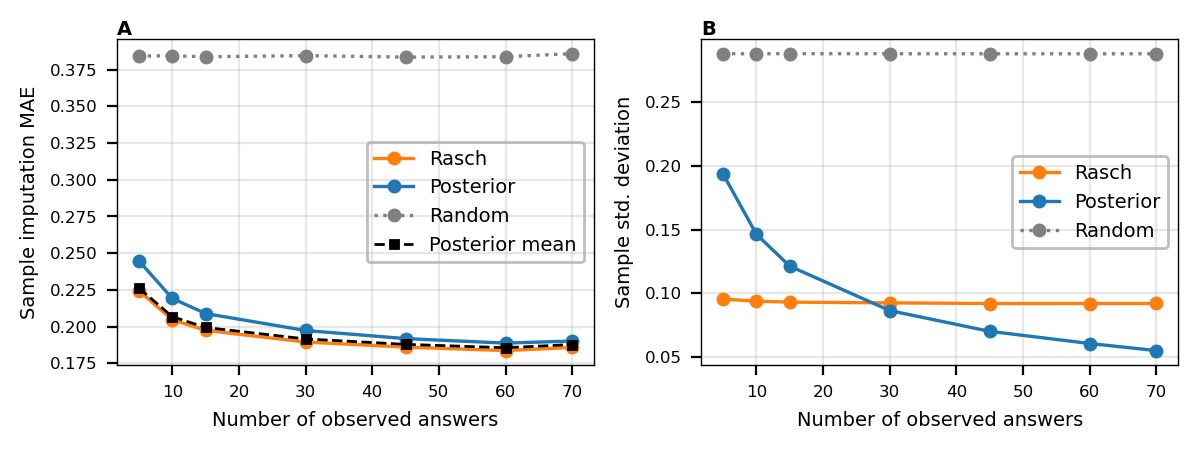

In [4]:
# Population sweep, matched to the point-estimate study (app:point-estimate):
# the same model already fitted above (prior_variance=0.25, 10 iterations),
# a per-user random hold-out (rng.choice, fresh per user and per n_obs), the
# same observation grid as the point-estimate table, and metrics averaged over
# all candidates.
from pathlib import Path
from src.visualization import apply_defaults, figsize

N_OBSERVED_LIST = [5, 10, 15, 30, 45, 60, 70]
NUM_SAMPLES = 200
num_options = 5   # Rasch CRF: 5-point Smartvote scale
variance = 0.1    # Rasch CRF bandwidth

Y = reactions.values  # (N, K) scaled answers; candidates fully observed
n_users, n_items = Y.shape
rng = np.random.default_rng(42)

agg = {(label, n): {'mae': [], 'std': []}
       for label in ('Rasch', 'Posterior', 'Random')
       for n in N_OBSERVED_LIST}
pmean = {n: [] for n in N_OBSERVED_LIST}  # posterior-mean point-estimate MAE

for u in range(n_users):
    full = pd.Series(Y[u], index=xplore.items)
    for n in N_OBSERVED_LIST:
        obs_idx = rng.choice(n_items, size=n, replace=False)
        unobs = np.ones(n_items, dtype=bool)
        unobs[obs_idx] = False
        pa = full.iloc[obs_idx]
        y_true = Y[u][unobs]

        # Posterior-mean point estimate (the A.1 "Posterior mean" reference).
        pos = xplore.embed(pa)
        pred = xplore.predict(np.asarray(pos).reshape(1, -1))[0]
        pmean[n].append(np.mean(np.abs(pred[unobs] - y_true)))

        for method, label in [('rasch', 'Rasch'),
                               ('posterior', 'Posterior'),
                               ('random', 'Random')]:
            kw = dict(method=method, num_samples=NUM_SAMPLES)
            if method == 'rasch':
                kw.update(num_options=num_options, variance=variance)
            s = xplore.sample_answers(pa, **kw)
            agg[(label, n)]['mae'].append(
                np.mean(np.abs(s[:, unobs].mean(axis=0) - y_true)))
            agg[(label, n)]['std'].append(s[:, unobs].std(axis=0).mean())

rows = []
for label in ('Rasch', 'Posterior', 'Random'):
    for n in N_OBSERVED_LIST:
        rows.append({'n_obs': n, 'method': label,
                     'mae': np.mean(agg[(label, n)]['mae']),
                     'mean_std': np.mean(agg[(label, n)]['std'])})
res_df = pd.DataFrame(rows)
map_maes = [np.mean(pmean[n]) for n in N_OBSERVED_LIST]

apply_defaults()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize(width_frac=1.0, aspect=0.38))

for method, color, ls in [('Rasch', 'tab:orange', '-'),
                          ('Posterior', 'tab:blue', '-'),
                          ('Random', 'gray', ':')]:
    sub = res_df[res_df['method'] == method]
    ax1.plot(sub['n_obs'], sub['mae'], marker='o', color=color, label=method,
             markersize=4, ls=ls)
    ax2.plot(sub['n_obs'], sub['mean_std'], marker='o', color=color, label=method,
             markersize=4, ls=ls)

ax1.plot(N_OBSERVED_LIST, map_maes, marker='s', color='black', ls='--', lw=1,
         markersize=3, label='Posterior mean')

ax1.set_xlabel('Number of observed answers')
ax1.set_ylabel('Sample imputation MAE')
ax2.set_xlabel('Number of observed answers')
ax2.set_ylabel('Sample std. deviation')
ax1.legend()
ax2.legend()
fig.text(0, 1, 'A', va='bottom', ha='left', weight='bold', transform=ax1.transAxes)
fig.text(0, 1, 'B', va='bottom', ha='left', weight='bold', transform=ax2.transAxes)
plt.tight_layout(rect=[0, 0, 1, 0.95])
FIG_DIR = Path('../../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / 'sampling_strategies_smartvote_2023.pdf')
plt.show()